## Clasificación y k-Vecinos más Cercanos

### 1. Clasificación

En aprendizaje supervisado se dispone de ejemplos para los cuales se conocen tanto los atributos de entrada como la salida correcta.

En un problema de clasificación, cada instancia puede representarse mediante un vector de atributos:

$$
\mathbf{x} = [x_1,x_2,\ldots,x_m]
$$

y la salida pertenece a un conjunto finito de clases:

$$
y \in \{c_1,c_2,\ldots,c_K\}
$$

El objetivo es aprender, a partir de ejemplos etiquetados, una función:

$$
f:\mathcal{X}\rightarrow\mathcal{Y}
$$

capaz de asignar una clase a nuevas observaciones.

Por ejemplo, si se utilizan medidas de una flor como atributos, un clasificador puede aprender a asignar cada nueva observación a una especie de Iris.

#### 1.1 Algunas formas de caracterizar un clasificador

Un problema puede ser:

- **Binario:** existen dos clases posibles.
- **Multiclase:** existen más de dos clases posibles.

Un clasificador también puede describirse según el tipo de salida que produce:

- **Determinístico:** entrega directamente una etiqueta de clase.
- **Probabilístico:** además puede estimar un grado de pertenencia o probabilidad para cada clase.

Según la forma de la frontera de decisión, puede hablarse de:

- **Lineal:** separa las clases mediante una frontera lineal.
- **No lineal:** permite fronteras de decisión más complejas.

También puede distinguirse el objetivo con el que se utiliza el modelo:

- **Predictivo:** interesa principalmente predecir correctamente la clase de una nueva instancia.
- **Descriptivo:** interesa además identificar qué características permiten diferenciar las clases o justificar la decisión. Un árbol de decisión es un ejemplo natural porque, además de clasificar, permite observar las reglas utilizadas.

Estas categorías no son necesariamente excluyentes. Un mismo modelo puede ser útil tanto para predecir como para describir.

#### 1.2 Separación de los datos

Para estimar el desempeño sobre observaciones no utilizadas durante el ajuste, los datos se separan en conjuntos con funciones diferentes.

En los ejemplos de esta práctica utilizaremos:

- **Entrenamiento:** datos usados para ajustar el modelo.
- **Validación:** datos usados para comparar configuraciones del modelo, cuando sea necesario.
- **Prueba:** datos reservados para la evaluación final.

La proporcion de las clases debe conservarse en las particiones cuando sea posible  utilizando `stratify=y` en `train_test_split`.

### 2. k-Vecinos más Cercanos (KNN - K Nearest Neighbors)

KNN es un algoritmo de aprendizaje supervisado basado en instancias.

Para clasificar una nueva observación:

1. calcula la distancia entre la observación y las muestras de entrenamiento
2. selecciona los $K$ vecinos más cercanos
3. asigna la clase más frecuente entre esos vecinos.

KNN se denomina un algoritmo de **aprendizaje perezoso** porque en lugar de aprender una función paramétrica durante el entrenamiento, conserva los datos y realiza el trabajo principal cuando debe predecir una nueva observación.


#### 2.1 Métricas de distancia

La familia de distancias de Minkowski puede escribirse como:

$$
d(\mathbf{x},\mathbf{z}) =
\left(
\sum_{j=1}^{m}|x_j-z_j|^p
\right)^{1/p}
$$

Dos casos particularmente importantes son:

##### Distancia Manhattan

Para $p=1$:

$$
d_1(\mathbf{x},\mathbf{z}) =
\sum_{j=1}^{m}|x_j-z_j|
$$

##### Distancia Euclídea

Para $p=2$:

$$
d_2(\mathbf{x},\mathbf{z}) =
\sqrt{
\sum_{j=1}^{m}(x_j-z_j)^2
}
$$

Minkowski es una **familia general** que contiene a Manhattan y Euclídea como casos particulares. En esta práctica compararemos principalmente estas dos métricas porque tienen una interpretación clara y son suficientes para estudiar cómo cambia el concepto de cercanía.

#### 2.2 Escala de los atributos

Como KNN trabaja directamente con distancias, la escala de los atributos puede modificar qué observaciones son consideradas vecinas.

#### 2.3 Elección de $K$

El número de vecinos $K$ controla cuán local es la decisión.

- Con valores pequeños de $K$, la predicción depende fuertemente de observaciones muy cercanas.
- Al aumentar $K$, la decisión utiliza información de una región más amplia del espacio.

Por eso, $K$ es un **hiperparámetro** y no debería elegirse utilizando el conjunto de prueba.

#### 2.4 ¿Qué ocurre si hay empate?

La regla de votación puede producir empates.

Por ejemplo, con $K=4$ en un problema binario:

$$
A,\ A,\ B,\ B
$$

ninguna clase obtiene mayoría.

Elegir un valor impar de $K$ evita este empate por cantidad de votos en un problema **binario**, pero no necesariamente en uno **multiclase**. Por ejemplo, con $K=5$:

$$
A,\ A,\ B,\ B,\ C
$$

todavía existe un empate entre $A$ y $B$.

### 3. Evaluación de desempeño de un clasificador

No existe una única métrica adecuada para todos los problemas. La elección depende de qué errores sean más importantes en la aplicación.

La herramienta básica para analizar los errores es la **matriz de confusión**.

#### 3.1 Matriz de confusión

La siguiente representación utiliza la misma convención que `sklearn.metrics.confusion_matrix`: las **filas corresponden a la realidad** y las **columnas a la predicción**.

<div style="max-width:720px; margin:18px auto; font-family:Arial, sans-serif;">
  <div style="text-align:center; font-size:22px; font-weight:bold; margin-bottom:8px;">
    Predicción
  </div>
  <table style="border-collapse:collapse; width:100%; text-align:center; font-size:16px;">
    <tr>
      <th style="border:1px solid #000; padding:10px;">Realidad \ Predicción</th>
      <th style="border:1px solid #000; padding:10px;">Negativa</th>
      <th style="border:1px solid #000; padding:10px;">Positiva</th>
    </tr>
    <tr>
      <th style="border:1px solid #000; padding:12px;">Negativa</th>
      <td style="border:1px solid #000; padding:18px; background:#034e00;">
        <b>VN / TN</b><br>Verdadero negativo
      </td>
      <td style="border:1px solid #000000; padding:18px; background:#580000;">
        <b>FP</b><br>Falso positivo
      </td>
    </tr>
    <tr>
      <th style="border:1px solid #000; padding:12px;">Positiva</th>
      <td style="border:1px solid #000; padding:18px; background:#580000;">
        <b>FN</b><br>Falso negativo
      </td>
      <td style="border:1px solid #000; padding:18px; background:#034e00;">
        <b>VP / TP</b><br>Verdadero positivo
      </td>
    </tr>
  </table>
</div>

Interpretación:

- **VP:** el caso era positivo y el modelo predijo positivo.
- **VN:** el caso era negativo y el modelo predijo negativo.
- **FP:** el caso era negativo, pero el modelo predijo positivo.
- **FN:** el caso era positivo, pero el modelo predijo negativo.

La noción de positivo depende del problema. Es importante definir explícitamente cuál es la clase de interés.

#### 3.2 Accuracy

Mide la proporción total de predicciones correctas:

$$
Accuracy =
\frac{VP+VN}{VP+VN+FP+FN}
$$

Es útil como medida global cuando las clases no presentan un desbalance importante y cuando los distintos tipos de error tienen costos comparables.

#### 3.3 Precision

Responde a la pregunta:

> De todos los casos que el modelo predijo como positivos, ¿cuántos eran realmente positivos?

$$
Precision =
\frac{VP}{VP+FP}
$$

La precision es especialmente relevante cuando los **falsos positivos** son costosos.

#### 3.4 Recall

Responde a la pregunta:

> De todos los casos realmente positivos, ¿cuántos logró detectar el modelo?

$$
Recall =
\frac{VP}{VP+FN}
$$

El recall es especialmente relevante cuando los **falsos negativos** son costosos.

En un problema de detección de enfermedad, si definimos como clase positiva la presencia de la enfermedad, un falso negativo representa una persona enferma clasificada como sana. En ese contexto puede ser especialmente importante lograr un recall elevado.

#### 3.5 F1-score

F1 combina precision y recall mediante su media armónica:

$$
F_1 =
2\frac{Precision\cdot Recall}{Precision+Recall}
$$

Es útil cuando se desea una medida única que tenga en cuenta simultáneamente ambas métricas.

Esto no significa que F1 sea siempre mejor que accuracy: la métrica debe elegirse según el objetivo del problema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_iris, load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Actividades

> ### **Se espera como entrega**

> Esta Notebook resuelta con el agregado del grupo al final del nombre
>
> No se admitirán entregas en formato diferente a notebook (archivos .iynb)
>
> Ejemplo Actividad_Clustering_Segmentacion_clientes_grupo_X.ipynb (reemplazar X por el número del grupo)

### 4. Actividad 1 — Implementación manual de KNN con Iris

El objetivo de esta primera actividad es implementar el procedimiento de KNN sin utilizar `KNeighborsClassifier` de scikit learn

##### Dataset Iris
El dataset Iris es uno de los conjuntos de datos clásicos utilizados para introducir problemas de clasificación. Contiene 150 observaciones de flores, pertenecientes a tres especies:

- Iris setosa
- Iris versicolor
- Iris virginica

Para cada flor se registran cuatro atributos morfológicos, medidos en centímetros: longitud y ancho del sépalo, y longitud y ancho del pétalo. Cada especie contiene 50 observaciones, por lo que las clases están equilibradas.

En esta práctica se utilizarán únicamente la longitud y el ancho del pétalo como atributos de entrada. Esto permite trabajar con una representación sencilla del problema mientras se implementa manualmente el algoritmo KNN.

El objetivo es predecir la especie de una flor a partir de sus características.

**Pautas para dividir los datos**

Para simplificar la visualización conceptual, se utilizarán únicamente dos atributos:

- `petal length (cm)`
- `petal width (cm)`

La variable objetivo será la especie de Iris.

1. Cargar Iris usando `load_iris(as_frame=True)`.
2. Construir $X$ usando únicamente las columnas:
   - `petal length (cm)`
   - `petal width (cm)`
3. Utilizar `target` como $y$.
4. Dividir los datos (**entrenamiento y prueba**) utilizando:
   - `test_size=0.30`
   - `random_state=1`
   - `stratify=y`

In [7]:
iris_df = load_iris(as_frame=True).frame
X = iris_df[['petal length (cm)', 'petal width (cm)']]
y = iris_df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

Se proporciona la estructura de una clase y el cálculo de la distancia. Completar el método `predict()`.

Para cada punto de prueba deberá:

1. calcular la distancia a cada ejemplo de entrenamiento;
2. ordenar las distancias;
3. seleccionar los $K$ vecinos más cercanos;
4. obtener sus clases;
5. realizar la votación;
6. agregar la clase predicha a `y_pred`.

Puede utilizar `Counter` para realizar la votación.

In [8]:
class KNN:
    """Clasificador KNN.

    Parámetros
    ------------
    k : int
        número de vecinos cercanos
    p : int
        valor para selección de métrica (1: Manhattan, 2: Euclídea)
    """

    def __init__(self, k=3, p=2):
        self.k = k
        self.p = p

    def distancia(self, vec_1, vec_2, p=2):
        dim = len(vec_1)
        distance=0

        for d in range(dim):
            distance += (abs(vec_1[d]-vec_2[d]))**p

        distance = (distance)**(1/p)
        return distance

    def fit(self, X, y):
        """Entrenamiento del clasificador kNN, es un algoritmo 'perezoso'
        sólo almacena los datos y sus etiquetas
        Parameters
        ----------
        X : array
            vector de características.
        y : array
            clases asociadas a los datos.
        """
        self.X = np.asarray(X)
        self.y = np.asarray(y)
        self.n_datos = X.shape[0]

    def predict(self, x):
        """Función que realiza la predicción.
        Parameters
        ----------
        x : array
            vector de patrones de entrada.

        Returns
        -------
        vector de predicciones.
        """
        y_pred = []

        for punto_prueba in x:
            distancias = []
            # Distancia a cada ejemplo de entrenamiento
            for x_CE in self.X:
                d = self.distancia(punto_prueba, x_CE, self.p)
                distancias.append(d)

            # Ordenar y seleccionar los K vecinos más cercanos
            ind_ordenados = np.argsort(distancias)
            vecinos_cercanos = ind_ordenados[:self.k]

            # Obtener clases de los vecinos y votar las más vistas
            clases_vecinos = self.y[vecinos_cercanos]
            votos = Counter(clases_vecinos)
            clase_predicha = votos.most_common(1)[0][0]

            # Agregar predicción
            y_pred.append(clase_predicha)
        return np.asarray(y_pred)

Utilizar:

- $K=3$
- distancia Euclídea, es decir $p=2$

Calcular las predicciones sobre el conjunto de prueba y estimar la tasa de aciertos.

In [11]:
# Instanciar el modelo con K=3 y p=2 (distancia Euclídea)
knn = KNN(k=3, p=2)

# Ajustar con el conjunto de entrenamiento
knn.fit(X_train.values, y_train.values)

# Predecir sobre el conjunto de prueba
y_pred = knn.predict(X_test.values)

# Estimar la tasa de aciertos
tasa_aciertos = accuracy_score(y_test, y_pred)

print(f"Predicciones: {y_pred}")
print(f"Tasa de aciertos: {tasa_aciertos:.4f} ({tasa_aciertos * 100:.2f}%)")

iris = load_iris()
print(iris.target_names)

Predicciones: [2 0 0 1 1 1 2 1 2 0 0 2 0 1 0 1 2 1 1 2 2 0 1 2 1 1 1 2 0 2 0 0 1 1 2 2 0
 0 0 1 2 2 1 0 0]
Tasa de aciertos: 0.9778 (97.78%)
['setosa' 'versicolor' 'virginica']


### Resultados de la clasificación con KNN manual ($K=3$, distancia Euclídea $p=2$)

1. **Tamaño y balance de las particiones:**  
   El conjunto de prueba consta de 45 observaciones ($30\%$ del total de 150 instancias del dataset Iris). Al haberse utilizado una partición estratificada (`stratify=y`), cada una de las tres especies (iris setosa, iris versicolor e iris virginica) cuenta con 15 observaciones en el conjunto de evaluación.

2. **Rendimiento global del clasificador:**  
   La tasa de aciertos se define como la proporción de predicciones correctas sobre el total de instancias evaluadas:
   $$\text{Accuracy} = \frac{\text{Total de predicciones correctas}}{\text{Total de instancias}} = \frac{44}{45} \approx 0.9778 \quad (97.78\%)$$
   El modelo clasificó adecuadamente 44 de 45 flores del conjunto de prueba, cometiendo un único error de clasificación.

3. **Comportamiento en el espacio de atributos:**  
   * **Clase 0 (Iris setosa):** Presenta un $100\%$ de aciertos sin ninguna confusión.
   * **Clases 1 (Iris versicolor) y 2 (Iris virginica):** La única clasificación incorrecta ocurre en esa región limítrofe, donde una flor de prueba queda rodeada por mayoría por vecinos de la otra especie al evaluar sus K=3 observaciones más cercanas bajo la métrica Euclídea.

### 5. Actividad 2 — KNN con `scikit-learn`: reconocimiento de dígitos

##### Dataset Digits

El dataset Digits contiene imágenes de dígitos manuscritos correspondientes a las clases del 0 al 9.

El conjunto posee 1797 imágenes. Cada imagen tiene una resolución de $8 \times 8$ píxeles, por lo que cada instancia puede representarse mediante un vector de $8 \times 8 = 64$ atributos.

Cada atributo representa la intensidad de un píxel, con valores comprendidos entre 0 y 16. De esta manera, una imagen puede representarse tanto como una matriz de $8\times8$ píxeles como mediante un vector de 64 características utilizado por el clasificador.

El problema consiste en utilizar la información de esos píxeles para determinar qué dígito representa cada imagen.

Ahora se utilizará `KNeighborsClassifier` de scikit learn.

El objetivo de esta actividad es estudiar:

- cómo cambia el resultado al utilizar Manhattan o Euclídea;
- cómo influye el valor de $K$;
- cómo seleccionar una configuración usando validación;
- cómo interpretar una matriz de confusión multiclase.

In [12]:
digits = load_digits()

X_digits = digits.data
y_digits = digits.target

print("X shape:", X_digits.shape)
print("Classes:", np.unique(y_digits))
print("Pixel value range:", (X_digits.min(), X_digits.max()))

X shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: (np.float64(0.0), np.float64(16.0))


#### 5.1 Visualización de una observación

Cada fila de $X$ contiene $64$ valores, pero puede reorganizarse como una matriz de $8\times8$ para visualizar la imagen.

(8, 8)


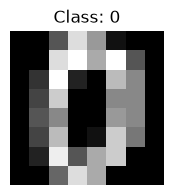

In [13]:
sample_index = 0

print(digits.images[sample_index].shape)

plt.figure(figsize=(2, 2))
plt.imshow(digits.images[sample_index], cmap="gray")
plt.title(f"Class: {y_digits[sample_index]}")
plt.axis("off")
plt.show()

#### 5.2 División de entrenamiento, validación y prueba

Utilizar:

- 70 % para **entrenamiento**
- 15 % para **validación**
- 15 % para **prueba**
- `random_state=42`
- muestreo estratificado.

puede hacerse en dos llamadas a `train_test_split`.

In [14]:
# Primera división: se separa 70% entrenamiento y 30% restante
X_train_d, X_temp, y_train_d, y_temp = train_test_split(
    X_digits, y_digits, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_digits
)

# Segunda división: se divide el 30% temporal en partes iguales (50% de 30% = 15% cada uno)
X_val_d, X_test_d, y_val_d, y_test_d = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(f"Muestras entrenamiento: {X_train_d.shape[0]} ({X_train_d.shape[0]/len(X_digits)*100:.1f}%)")
print(f"Muestras validación:    {X_val_d.shape[0]} ({X_val_d.shape[0]/len(X_digits)*100:.1f}%)")
print(f"Muestras prueba:        {X_test_d.shape[0]} ({X_test_d.shape[0]/len(X_digits)*100:.1f}%)")

Muestras entrenamiento: 1257 (69.9%)
Muestras validación:    270 (15.0%)
Muestras prueba:        270 (15.0%)


#### 5.3 Experimento: métrica de distancia y valor de $K$

Comparar:

- `metric="manhattan"`
- `metric="euclidean"`

para:

$$
K \in \{1,3,5,7,9,11,13,15\}
$$

Para cada combinación:

1. crear un `KNeighborsClassifier`;
2. ajustarlo con entrenamiento;
3. calcular métrica de validación `accuracy_score`;
4. almacenar el resultado.

In [15]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
distance_metrics = ["manhattan", "euclidean"]

# Estructura para almacenar las exactitudes de validación
results = {metric: [] for metric in distance_metrics}

for metric in distance_metrics:
    for k in k_values:
        # 1. Crear el clasificador
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # 2. Ajustar con el conjunto de entrenamiento
        knn.fit(X_train_d, y_train_d)
        
        # 3. Predecir y calcular accuracy sobre el conjunto de validación
        y_val_pred = knn.predict(X_val_d)
        acc_val = accuracy_score(y_val_d, y_val_pred)
        
        # 4. Almacenar el resultado
        results[metric].append(acc_val)
        print(f"Métrica: {metric:<9} | K = {k:2d} | Accuracy Validación: {acc_val:.4f}")

Métrica: manhattan | K =  1 | Accuracy Validación: 0.9778
Métrica: manhattan | K =  3 | Accuracy Validación: 0.9778
Métrica: manhattan | K =  5 | Accuracy Validación: 0.9704
Métrica: manhattan | K =  7 | Accuracy Validación: 0.9667
Métrica: manhattan | K =  9 | Accuracy Validación: 0.9630
Métrica: manhattan | K = 11 | Accuracy Validación: 0.9630
Métrica: manhattan | K = 13 | Accuracy Validación: 0.9593
Métrica: manhattan | K = 15 | Accuracy Validación: 0.9556
Métrica: euclidean | K =  1 | Accuracy Validación: 0.9778
Métrica: euclidean | K =  3 | Accuracy Validación: 0.9778
Métrica: euclidean | K =  5 | Accuracy Validación: 0.9815
Métrica: euclidean | K =  7 | Accuracy Validación: 0.9778
Métrica: euclidean | K =  9 | Accuracy Validación: 0.9704
Métrica: euclidean | K = 11 | Accuracy Validación: 0.9741
Métrica: euclidean | K = 13 | Accuracy Validación: 0.9630
Métrica: euclidean | K = 15 | Accuracy Validación: 0.9630


### Análisis de resultados y selección de hiperparámetros

A partir del experimento comparativo entre métricas de distancia y distintos valores de K evaluados sobre el conjunto de validación (270 muestras), se desprenden las siguientes observaciones:

1. **Métrica de distancia:**  
   La distancia Euclídea logró mejores resultados que la distancia Manhattan en la mayoría de los casos. Al comparar imágenes donde cada píxel tiene un valor de brillo, la distancia Euclídea resulta más adecuada para medir el parecido global entre las formas de los números.

2. **Efecto de la cantidad de vecinos (K):**  
   * Con valores chicos de K (K= 1, 3, 5), el clasificador alcanza la mayor exactitud porque decide mirando únicamente los ejemplos que más se parecen visualmente.
   * A medida que K aumenta (K >= 7), el desempeño empieza a bajar en ambas métricas. Esto pasa porque al tomar demasiados vecinos, entran en la votación números distintos que comparten trazos parecidos (como el 3 con el 8, o el 1 con el 7), lo que genera confusiones.

3. **Configuración elegida:**  
   * **Mejor combinación:** K = 5 con distancia Euclídea.
   * **Exactitud en validación:** `0.9815` (98.15%).

Con estos parámetros se reentrena el modelo uniendo entrenamiento y validación para luego hacer la prueba final.

#### 5.4 Representación de los resultados

Graficar `validation_accuracy` en función de $K$, utilizando una curva para cada métrica.

Luego identificar la combinación con mayor accuracy de validación.

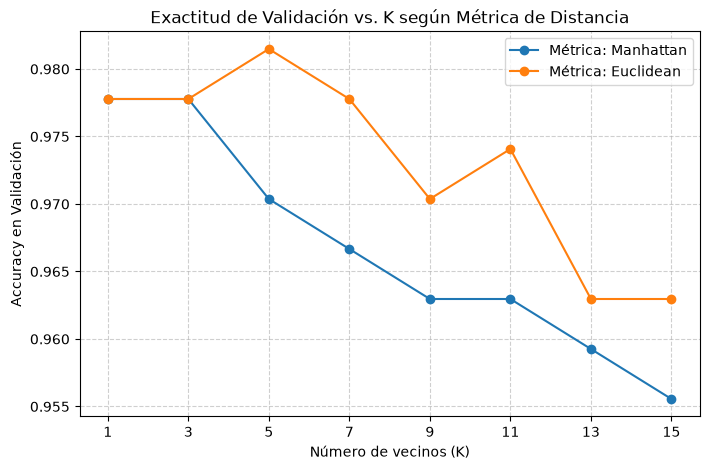

Mejor configuración: K = 5 con distancia euclidean (Accuracy Validación: 0.9815)


In [16]:
plt.figure(figsize=(8, 5))

for metric in distance_metrics:
    plt.plot(k_values, results[metric], marker='o', label=f"Métrica: {metric.capitalize()}")

plt.title("Exactitud de Validación vs. K según Métrica de Distancia")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy en Validación")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Identificación automática de la mejor combinación
best_acc = 0
best_config = (None, None)

for metric in distance_metrics:
    for k, acc in zip(k_values, results[metric]):
        if acc > best_acc:
            best_acc = acc
            best_config = (k, metric)

print(f"Mejor configuración: K = {best_config[0]} con distancia {best_config[1]} (Accuracy Validación: {best_acc:.4f})")

### Grafico y selección de la mejor configuración

A partir de la curva de exactitud en el conjunto de validación, se observa lo siguiente:

1. **Comparación de distancias:**
   La distancia euclídea (naranja) es superior a la distancia manhattan (azul) en casi  todos los valores de K. Mide de forma más equilibrada el parecido general entre los trazos de los números.

2. **Efecto del valor de K:**
   Con K=5, la distancia Euclídea alcanza su punto más alto.
   A partir de K >= 7, la exactitud empieza a decaer en ambas métricas. Esto ocurre porque al tomar demasiados vecinos, empiezan a votar números distintos que comparten ciertas curvas o trazos similares.

3. **Configuración seleccionada:** Se repite lo elegido en el apartado anterior:
   * **Mejor métrica:** Euclídea
   * **Mejor K:** 5
   * **Accuracy en validación:** `0.9815` (98.15%)

#### 5.5 Evaluación final en prueba

Una vez elegidos la métrica y $K$ usando validación:

1. unir entrenamiento y validación (`X_train_final_d, y_train_final_d`);
2. entrenar un nuevo `KNeighborsClassifier` con esos datos;
3. evaluar **una sola vez** sobre prueba (`X_test_d, y_test_d`).

In [ ]:
# Unir los conjuntos de entrenamiento y validación
X_train_final_d = np.vstack([X_train_d, X_val_d])
y_train_final_d = np.concatenate([y_train_d, y_val_d])

# Entrenar el clasificador final con la mejor configuración seleccionada
best_k, best_metric = best_config
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_final.fit(X_train_final_d, y_train_final_d)

# Evaluar una sola vez sobre el conjunto de prueba
y_test_pred_d = knn_final.predict(X_test_d)
acc_test = accuracy_score(y_test_d, y_test_pred_d)

print(f"--- Evaluación Final sobre Conjunto de Prueba ---")
print(f"Configuración utilizada: K={best_k}, métrica={best_metric}")
print(f"Accuracy en Prueba: {acc_test:.4f} ({acc_test * 100:.2f}%)")

--- Evaluación Final sobre Conjunto de Prueba ---
Configuración utilizada: K=5, métrica=euclidean
Accuracy en Prueba: 0.9963 (99.63%)


Una vez seleccionada la mejor configuración mediante el conjunto de validación (K=5, distancia Euclídea), se reentrenó el clasificador utilizando la unión de los conjuntos de entrenamiento y validación ($85\%$ de los datos totales) para maximizar la cantidad de ejemplos disponibles, para evaluar los 270 datos restantes en el conjunto de prueba.

#### Interpretación:
El clasificador demostró una capacidad de generalización prácticamente perfecta, acertando casi todas las imágenes de prueba, errando en solo una de ellas:


 $$\text{Accuracy} = \frac{\text{Total de predicciones correctas}}{\text{Total de instancias}} = \frac{269}{270} \approx 0.9963 \quad (99.63\%)$$


Al haber mantenido el conjunto de prueba completamente aislado durante la etapa de selección de hiperparámetros, esta métrica representa una estimación realista y no sesgada del desempeño del modelo ante datos que nunca antes había procesado.

#### 5.6 Matriz de confusión de `Digits`

En un problema multiclase la matriz tiene una fila y una columna por clase.

En `Digits` tendremos diez clases:

$$
0,1,2,\ldots,9
$$

por lo que la matriz de confusión será de tamaño $10\times 10$.

- Los elementos de la **diagonal principal** corresponden a predicciones correctas.
- Un valor fuera de la diagonal indica que una clase real fue confundida con otra clase.

Esta matriz permitirá analizar qué dígitos resultan más difíciles de distinguir.

Construir la matriz de confusión usando:

- `confusion_matrix(y_test_d, y_test_pred_d)`
- `ConfusionMatrixDisplay`

**Recordatorio**

- filas = clase real;
- columnas = clase predicha;
- diagonal principal = predicciones correctas.

#### Consignas

1. Construya y grafique la matriz.
2. Identifique si algún digito presenta errores.

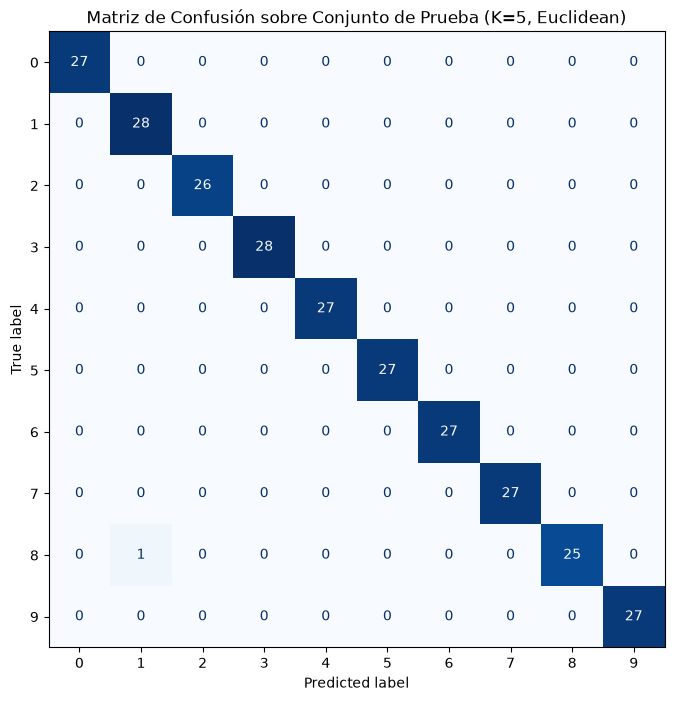

In [18]:
cm = confusion_matrix(y_test_d, y_test_pred_d)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_digits))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Matriz de Confusión sobre Conjunto de Prueba (K={best_k}, {best_metric.capitalize()})")
plt.show()

### Lectura de la matriz
**Diagonal principal:** 269 de 270 instancias, lo que confirma la exactitud del 99.63% obtenida.

**Las clases del 0 al 7 y la clase 9** presentan un 100% de aciertos sin ningún falso positivo ni falso negativo en este conjunto de prueba.

### Identificación del error:
**El único dígito con error fue el 8:**
En la fila correspondiente a la clase real 8 (True label = 8), se observa que 25 muestras fueron clasificadas correctamente como 8. Hay 1 muestra en la columna 1 (Predicted label = 1).

Hubo una imagen manuscrita que en la realidad era un **8**, pero el modelo la predijo como un **1**. Esto prodria ser porque la persona escribió un 8 muy alargado, comprimido o con los bucles casi cerrados/incompletos, haciendo que en una resolución baja de $8\times8$ píxeles su silueta se asemeje más a los trazos verticales de los ejemplos de la clase 1 en el espacio euclídeo.

#### 5.7 ¿qué ocurre si hay un empate en la votación?

Hasta ahora utilizamos KNN suponiendo que entre los vecinos existe una clase con mayor cantidad de votos. Sin embargo, en un problema multiclase pueden producirse empates.

Analizaremos una observación particular del conjunto de prueba de `Digits`. Para ello utilizaremos temporalmente $K=4$ y $K=5$, manteniendo la distancia Euclídea.

La función `kneighbors()` permite consultar directamente cuáles son los vecinos utilizados por el clasificador y sus distancias.

Ejecute el siguiente código y analice los resultados.

`X_train_final_d, y_train_final_d` corresponden a los **conjuntos de entrenamiento y validación unidos**

`X_test_d, y_test_d` corresponde al conjunto de prueba


In [19]:
# DEFINIR EN BASE A LOS DATOS DE ENTRENAMIENTO, VALIDACION Y PRUEBA USADOS
X_test_d = X_test_d
y_test_d = y_test_d
X_train_final_d = X_train_final_d
y_train_final_d = y_train_final_d


sample_index = 168
sample = X_test_d[sample_index].reshape(1, -1)

for k in [4, 5]:

    knn_tie = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform"
    )

    knn_tie.fit(X_train_final_d, y_train_final_d)

    distances, indices = knn_tie.kneighbors(sample)
    neighbor_labels = y_train_final_d[indices[0]]
    prediction = knn_tie.predict(sample)[0]

    print(f"K = {k}")
    print("Neighbor labels:", neighbor_labels)
    print("Distances:", np.round(distances[0], 2))
    print("Prediction:", prediction)
    print()

K = 4
Neighbor labels: [6 6 8 8]
Distances: [23.79 24.45 27.51 29.24]
Prediction: 6

K = 5
Neighbor labels: [6 6 8 8 1]
Distances: [23.79 24.45 27.51 29.24 29.72]
Prediction: 6



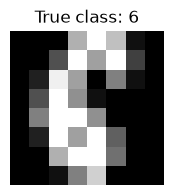

In [20]:
plt.figure(figsize=(2, 2))
plt.imshow(X_test_d[sample_index].reshape(8, 8), cmap="gray")
plt.title(f"True class: {y_test_d[sample_index]}")
plt.axis("off")
plt.show()

#### Preguntas

1. ¿Qué ocurre con la votación cuando $K=4$?
2. ¿Qué ocurre cuando $K=5$?
3. ¿Utilizar un valor impar de $K$ garantiza que no pueda existir un empate?
4. ¿Qué clase predice `KNeighborsClassifier` en cada caso?
5. Investigue: ¿qué criterios utiliza `scikit-learn` para resolver un empate entre clases?

1. **¿Qué ocurre con la votación cuando $K=4$?**  
   Ocurre un **empate exacto**: entre los 4 vecinos más cercanos hay 2 instancias de la clase 6 y 2 instancias de la clase 8. Ninguna clase alcanza mayoría de votos.

2. **¿Qué ocurre cuando $K=5$?**  
   Se mantiene el empate por el primer puesto: los 5 vecinos más cercanos corresponden a dos muestras de la clase 6, dos muestras de la clase 8 y una muestra de la clase 1. Las clases 6 y 8 siguen empatadas con 2 votos cada una en el primer puesto.

3. **¿Utilizar un valor impar de K garantiza que no pueda existir un empate?**  
   **No.** Un valor impar de K solo previene empates en problemas **binarios** (de 2 clases). En problemas **multiclase** (como Digits, que cuenta con 10 clases posibles, los números del 0 al 9), la dispersión de votos entre varias etiquetas puede generar empates aun con K impar, como ocurrió con K=5, donde la distribución fue 2, 2, 1.

4. **¿Qué clase predice `KNeighborsClassifier` en cada caso?**  
   En ambos casos predice la clase **6** (que además coincide con la clase real de la imagen, `True class: 6`).

5. **Investigue: ¿qué criterios utiliza `scikit-learn` para resolver un empate entre clases?**  
   Cuando varias clases obtienen la misma cantidad de votos y el parámetro es `weights="uniform"`, `scikit-learn` desempata asignando la clase cuyo vecino aparece primero en la lista de distancias ordenadas (es decir, la clase del vecino más cercano de todos).

### 6. Actividad 3 — ¿Qué métrica de evaluación conviene usar?

#### Wisconsin Diagnostic Breast Cancer

El dataset Breast Cancer Wisconsin Diagnostic contiene información obtenida a partir de imágenes digitalizadas de muestras celulares de masas mamarias. Su objetivo es distinguir entre tumores benignos y malignos.

Contiene 569 observaciones y 30 atributos numéricos. Estos atributos describen propiedades de los núcleos celulares observados en las imágenes, tales como:

radio,
textura,
perímetro,
área,
suavidad,
compacidad,
concavidad,
puntos cóncavos,
simetría,
dimensión fractal.

Para cada una de estas características se incluyen diferentes descriptores estadísticos, lo que da lugar a las 30 variables disponibles. El conjunto contiene dos clases:

- 357 casos benignos
- 212 casos malignos

En la versión original de scikit-learn, las etiquetas están codificadas como: `0 = malignant` y `1 = benign`

#### Actividad

Usar $K=5$ y distancia Euclídea.

Para facilitar la interpretación de las métricas, recodificaremos la variable objetivo como:

- `1` = maligno = **clase positiva**
- `0` = benigno = **clase negativa**

Esto es importante porque precision y recall siempre se interpretan respecto de una clase positiva.

In [ ]:
cancer = load_breast_cancer(as_frame=True)

X_cancer = cancer.data

# Recodificado para que maligno sea la clase positiva
y_cancer = (cancer.target == 0).astype(int)

print("Positive class: malignant = 1")
print("Negative class: benign = 0")
print(y_cancer.value_counts().sort_index())

#### 6.1 División y escalado

Dividir en entrenamiento y prueba utilizando:

- `test_size=0.20`
- `random_state=42`
- `stratify=y_cancer`

Luego construir un pipeline:

`StandardScaler` $\rightarrow$ `KNeighborsClassifier`

con:

- `n_neighbors=5`
- `metric="euclidean"`

#### 6.2 Matriz de confusión

Construya la matriz de confusión.

Luego identifique:

- VP
- VN
- FP
- FN

**Responder:**

En este problema, ¿qué representa un falso negativo?

#### 6.3 Accuracy, precision, recall y F1

Calcule:

- `accuracy_score`
- `precision_score`
- `recall_score`
- `f1_score`

Recuerde que la clase positiva es `malignant = 1`.

**Responder:**

1. Si el objetivo principal fuera reducir los casos malignos no detectados, ¿qué métrica debería observarse especialmente?
2. ¿Por qué un modelo con accuracy alta puede seguir siendo inadecuado para una aplicación concreta?